In [1]:
import torch
import numpy as np

import matplotlib as mpl
# import matplotlib.pyplot as plt

# remove top and right axis from plots
mpl.rcParams["axes.spines.right"] = False
mpl.rcParams["axes.spines.top"] = False

In [2]:
from sbi import analysis as analysis

# sbi
from sbi import utils as utils
from sbi.inference import NPE, simulate_for_sbi
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)

from sbi.diagnostics import check_sbc, run_sbc
from sbi.analysis.plot import sbc_rank_plot

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [21]:
Dx, N = 0.01, 6
Tmax, dt = 2 * np.pi * 10, 0.01

### Data & FA Fitting

In [ ]:
from datasets.MyDataset import Dataset
from torch.utils.data import DataLoader

DATASET_PATH = '/Users/lauragarcialopez/Documents/uni/TFG/06.TFG/codes/data/'

# Load training dataset
train_dataset = Dataset(f"{DATASET_PATH}train_dataset__Dx={str(Dx)}_Tmax={Tmax}.json")
train_loader = DataLoader(train_dataset, batch_size=4000, shuffle=True)

# Load test dataset
test_dataset = Dataset(f"{DATASET_PATH}test_dataset__Dx={str(Dx)}_Tmax={Tmax}.json")
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

In [4]:
train_X, train_P = None, None
for x, p in train_loader:
    if train_X is None and train_P is None:
        train_X = x
        train_P = p
    else:
        train_X = torch.cat((train_X, x), dim=0)
        train_P = torch.cat((train_P, p), dim=0)

test_X, test_P = None, None
for x, p in test_loader:
    if test_X is None and test_P is None:
        test_X = x
        test_P = p
    else:
        test_X = torch.cat((test_X, x), dim=0)
        test_P = torch.cat((test_P, p), dim=0)

In [5]:
import matplotlib.pyplot as plt
from models.MyLOModel2D import find_level_set_constants

def plot_embeddings(codes, color, ls=False, p=0):
    n = codes.shape[-1]
    label_names = [f'$K_a$', f'$K_f$'] if ls else [f'$\lambda$', f'$b$']

    fig, axs = plt.subplots(n-1, n-1, figsize=(2*(n-1), 2*(n-1)))
    if n == 2:
        im = axs.scatter(codes[:, 0], codes[:, 1], c=color, cmap='viridis')
        plt.colorbar(im, label=label_names[p])
        plt.xlabel(f'Feature {2}')
        plt.ylabel(f'Feature {1}')
    else:
        for i in range(n-1):
            for j in range(n-1):
                if i <= j:
                    im = axs[i, j].scatter(codes[:, j+1], codes[:, i], c=color, cmap='viridis')
                    axs[i, j].grid()
                    if i == j:
                        axs[i, j].set_xlabel(f'Feature {j+2}')
                        axs[i, j].set_ylabel(f'Feature {i+1}')
                else:
                    axs[i, j].set_visible(False)
        cbar = fig.colorbar(im, ax=axs.ravel().tolist(), orientation='vertical', label=label_names[p])

    plt.suptitle(f'Embedding Space ({label_names[p]})')
    plt.show()

test_level_sets = find_level_set_constants(test_P)

In [ ]:
from sklearn.decomposition import FactorAnalysis
import joblib

MODEL_PATH = f'./trained_models/FA/'

fa = FactorAnalysis(n_components=N)

new_fa = False
if new_fa:
    fa.fit_transform(train_X)
    joblib.dump(fa, f'{MODEL_PATH}FA.pkl')
else:
    fa = joblib.load(f'{MODEL_PATH}FA.pkl')

test_X_fa = fa.transform(test_X)

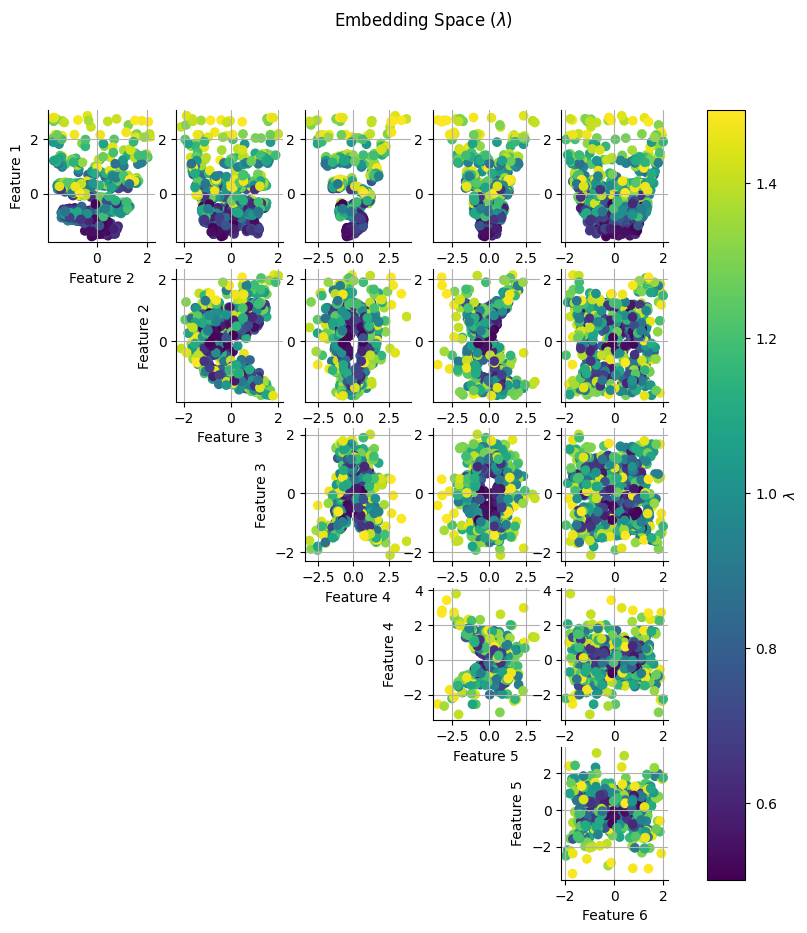

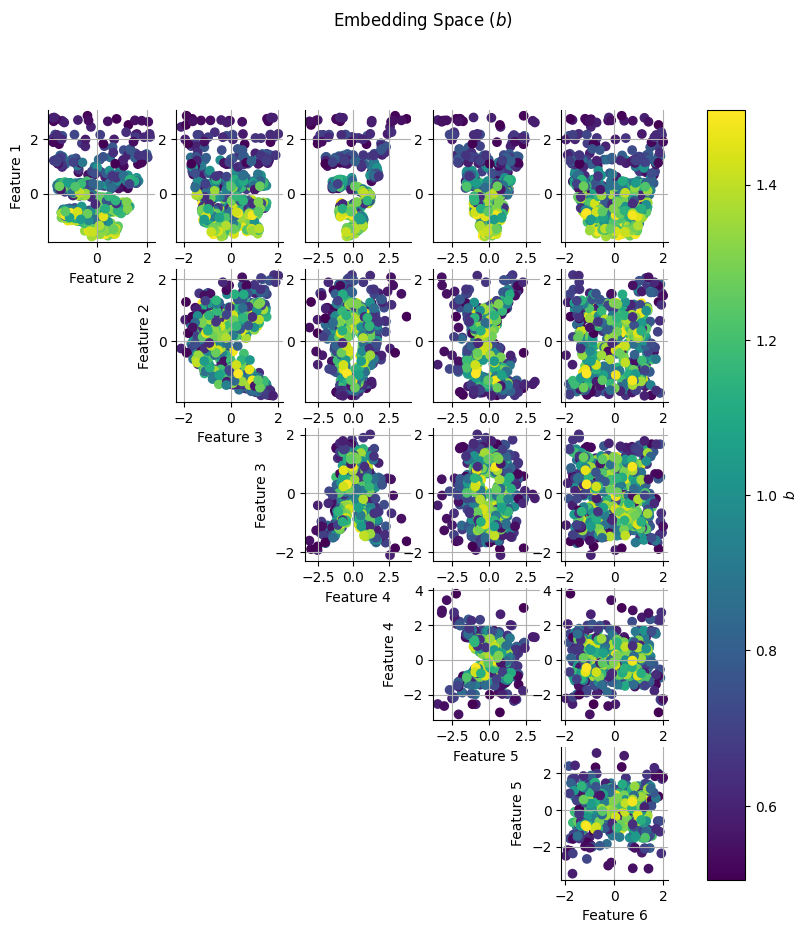

In [7]:
plot_embeddings(test_X_fa, test_P[:, 0], p=0)
plot_embeddings(test_X_fa, test_P[:, 1], p=1)

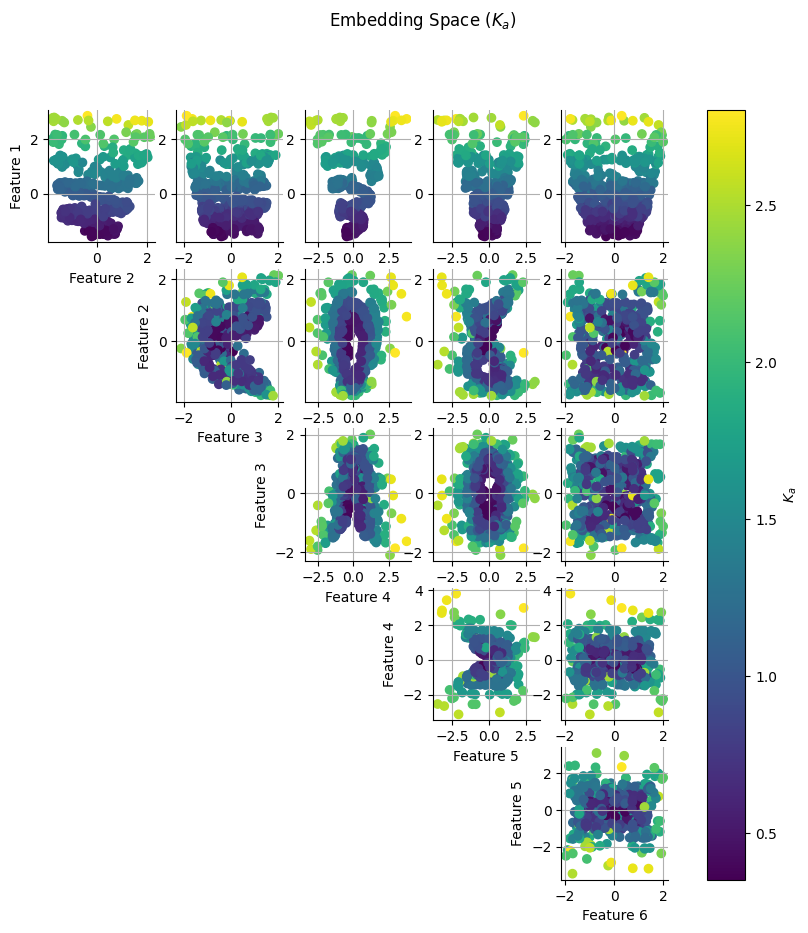

In [8]:
plot_embeddings(test_X_fa, test_level_sets['K_a'], ls=True, p=0)

### Simulator

In [31]:
from models.MyLOModel2D import create_time_specs, run_LOModel

t = create_time_specs(Tmax, dt)

def simulator(params):
    simulation = run_LOModel(params.squeeze(), t, dt, Dx=Dx)
    return torch.tensor(fa.transform(simulation['x'].unsqueeze(0))).squeeze(0)

#### SBI Training

In [32]:
prior_min, prior_max = [0.5] * 2, [1.5] * 2

prior = utils.torchutils.BoxUniform(
    low=torch.as_tensor(prior_min), high=torch.as_tensor(prior_max)
)

# Check prior, simulator, consistency
prior, num_parameters, prior_returns_numpy = process_prior(prior)
simulator = process_simulator(simulator, prior, prior_returns_numpy)
check_sbi_inputs(simulator, prior)

In [35]:
inference = NPE(prior=prior)

new_inference = True
if new_inference:
    num_simulations = 4000
    theta, x = simulate_for_sbi(simulator, proposal=prior, num_simulations=num_simulations, num_workers=4)

    inference = inference.append_simulations(theta, x)

    # train the density estimator and build the posterior
    density_estimator = inference.train()

    torch.save(inference._neural_net.state_dict(), f'{MODEL_PATH}SBI.pth')
else:
    theta_0 = prior.sample((10, ))
    x_0 = simulator(theta_0)
    print(x_0.shape)

    _ = inference.append_simulations(theta_0, x_0).train(max_num_epochs=0)

    inference._neural_net.load_state_dict(torch.load(f'{MODEL_PATH}SBI.pth'))

posterior = inference.build_posterior()

  0%|          | 0/4000 [00:00<?, ?it/s]

 Neural network successfully converged after 136 epochs.

In [36]:
obs_params1, obs_params2 = torch.tensor([[1, 1]]), torch.tensor([[0.75, 0.75]])

obs_trace1 = run_LOModel(obs_params1.squeeze(), t, dt, Dx=Dx)
obs_trace2 = run_LOModel(obs_params2.squeeze(), t, dt, Dx=Dx)

obs1 = fa.transform(obs_trace1['x'].unsqueeze(0))
obs2 = fa.transform(obs_trace2['x'].unsqueeze(0))

### Observation 1 - $\theta_1=(1, 1)$

Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

/var/folders/m4/cjl7ypxj3m5dgvkmsttj663m0000gn/T/ipykernel_37364/3883884944.py:4: DeprecationWarning: you passed deprecated arguments **kwargs: ['points_offdiag', 'points_colors'], use fig_kwargs instead. We continue calling the deprecated pairplot function
  fig, axes = analysis.pairplot(


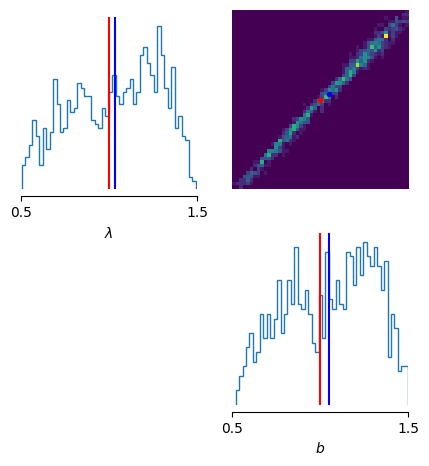

In [42]:
samples1 = posterior.sample((1000, ), x = obs1)
mean_params1 = samples1.mean(axis=0)

fig, axes = analysis.pairplot(
    samples1,
    limits=[[prior_min[ii], prior_max[ii]] for ii in range(len(prior_min))],
    ticks=[[prior_min[ii], prior_max[ii]] for ii in range(len(prior_min))],
    figsize=(5, 5),
    points_offdiag={"markersize": 6},
    points_colors=["r", "b"],
    points=[obs_params1, mean_params1],
    labels=[r'$\lambda$', r'$b$'],
)

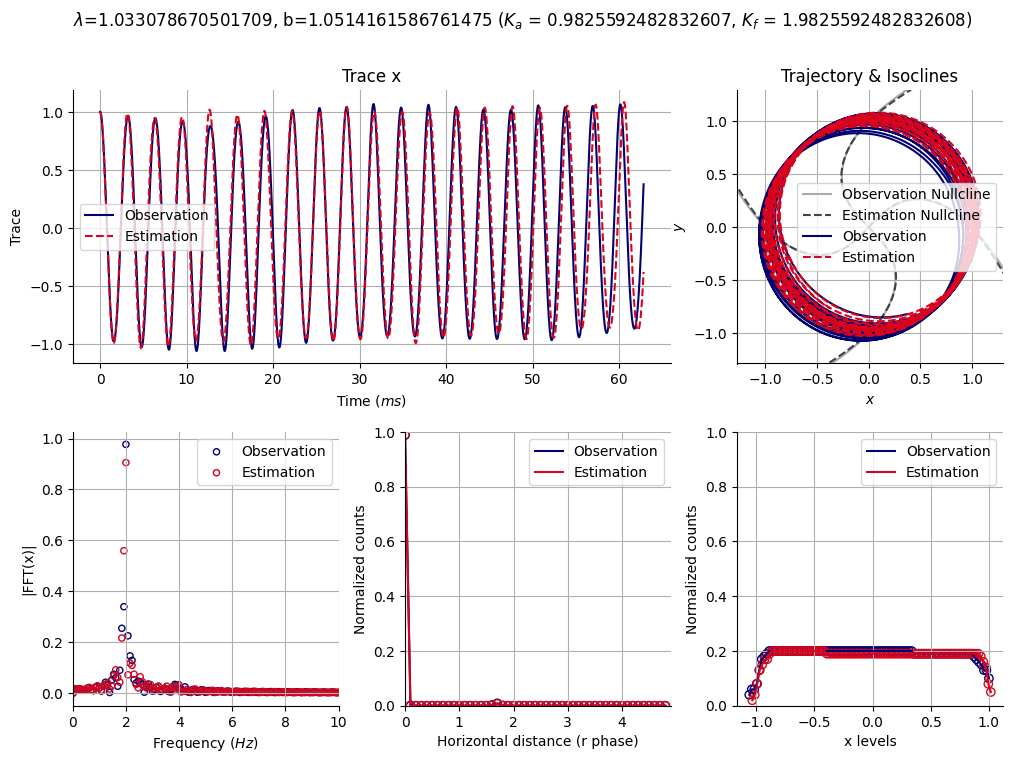

In [43]:
from models.MyLOModel2D import plot_reconstructions

trace1 = run_LOModel(mean_params1, t, dt, Dx=Dx)
plot_reconstructions(obs_trace1, trace1, obs_params1.unsqueeze(0), mean_params1.unsqueeze(0), 'x')

#### Metrics

The Wasserstein Distance for the distribution of the simulation values is 0.011484475957703497
The p-value for the Levene test is 0.0. 
 The Levene test says the variances of the error distributions the variances are different.


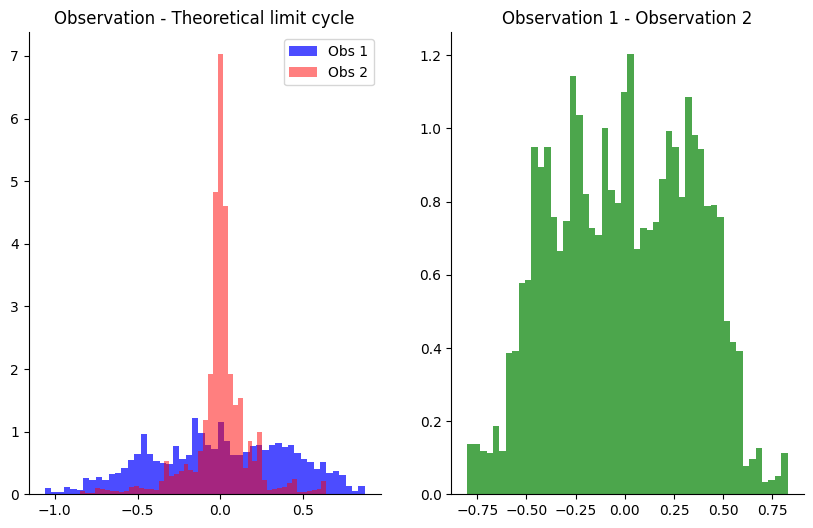

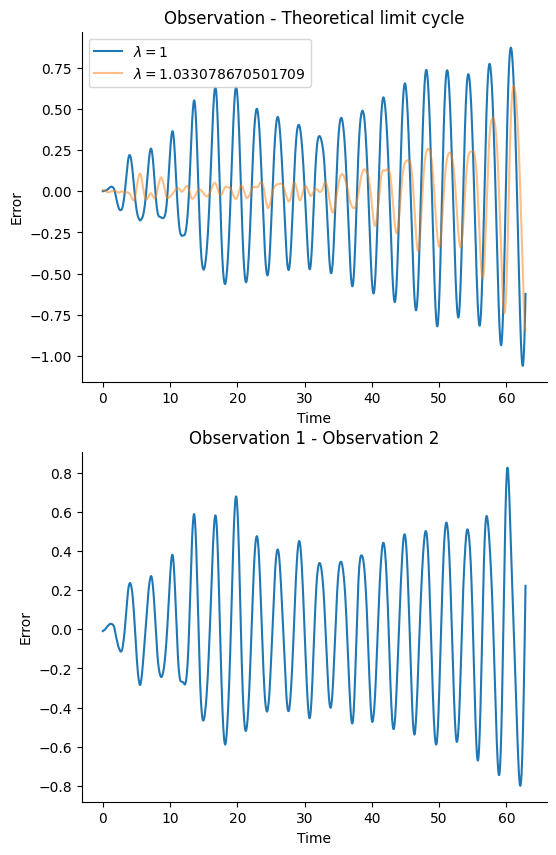

The Wasserstein Distance for the distribution of the error (wrt the ideal sinusoid) values is 0.23592731494802271


In [44]:
from metrics.WassErrDist import WassDist, WassErrDist

print(f"The Wasserstein Distance for the distribution of the simulation values is {WassDist(obs_trace1, trace1)}")
print(f"The Wasserstein Distance for the distribution of the error (wrt the ideal sinusoid) values is {WassErrDist(obs_trace1, trace1, obs_params1.squeeze(), mean_params1, plot=True)}")

### Observation 2 - $\theta_2=(0.75, 0.75)$

Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

/var/folders/m4/cjl7ypxj3m5dgvkmsttj663m0000gn/T/ipykernel_37364/1824077530.py:4: DeprecationWarning: you passed deprecated arguments **kwargs: ['points_offdiag', 'points_colors'], use fig_kwargs instead. We continue calling the deprecated pairplot function
  fig, axes = analysis.pairplot(


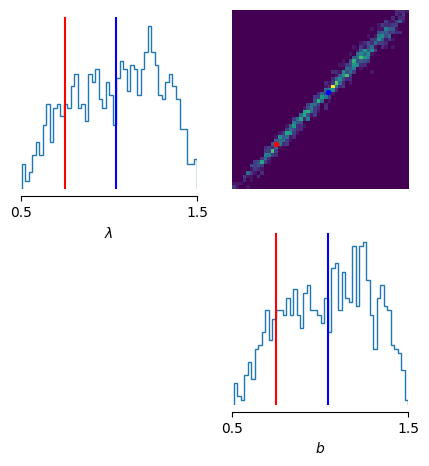

In [45]:
samples2 = posterior.sample((1000, ), x = obs2)
mean_params2 = samples2.mean(axis=0)

fig, axes = analysis.pairplot(
    samples2,
    limits=[[prior_min[ii], prior_max[ii]] for ii in range(len(prior_min))],
    ticks=[[prior_min[ii], prior_max[ii]] for ii in range(len(prior_min))],
    figsize=(5, 5),
    points_offdiag={"markersize": 6},
    points_colors=["r", "b"],
    points=[obs_params2, mean_params2],
    labels=[r'$\lambda$', r'$b$'],
)

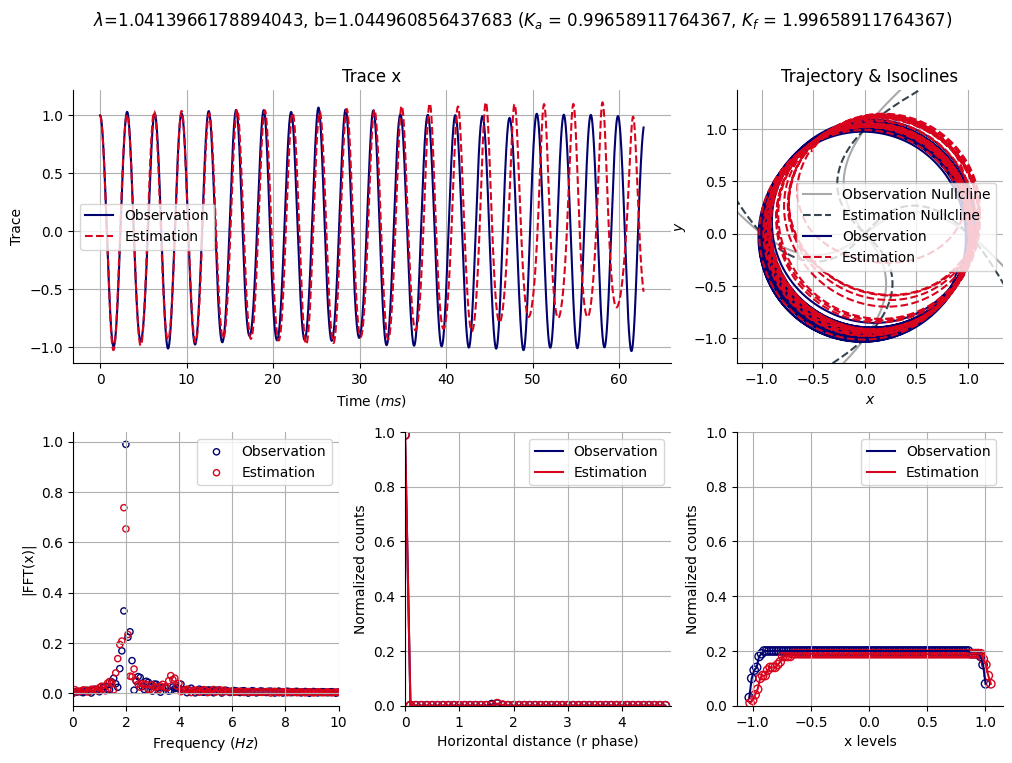

In [46]:
trace2 = run_LOModel(mean_params2, t, dt, Dx=Dx)
plot_reconstructions(obs_trace2, trace2, obs_params2.unsqueeze(0), mean_params2.unsqueeze(0), 'x')

#### Metrics

The Wasserstein Distance for the distribution of the simulation values is 0.047111400506454224
The p-value for the Levene test is 0.0. 
 The Levene test says the variances of the error distributions the variances are different.


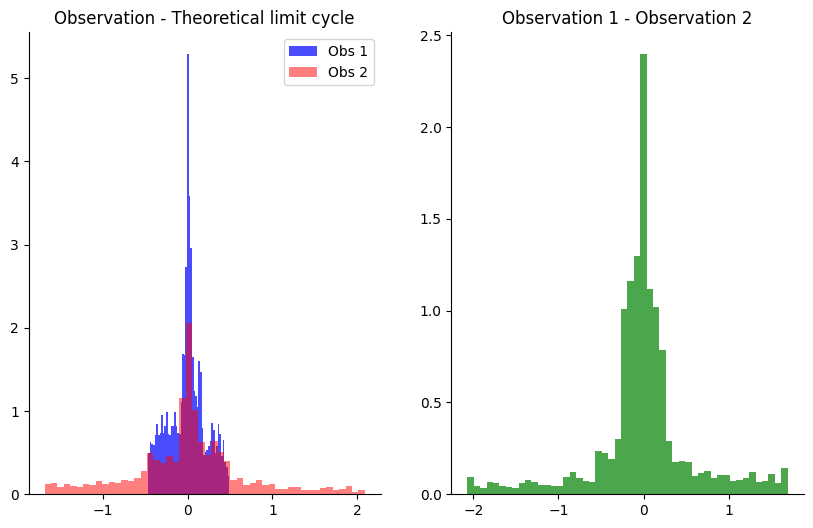

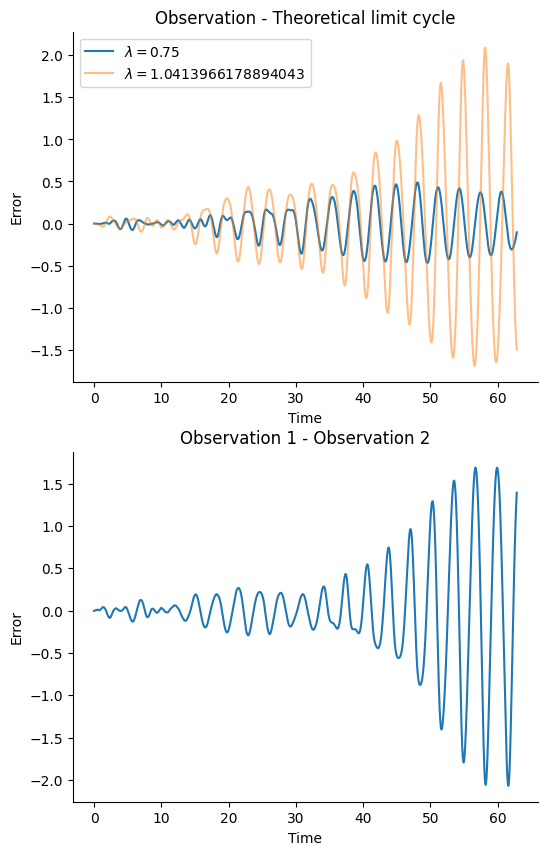

The Wasserstein Distance for the distribution of the error (wrt the ideal sinusoid) values is 0.2964358469905004


In [47]:
print(f"The Wasserstein Distance for the distribution of the simulation values is {WassDist(obs_trace2, trace2)}")
print(f"The Wasserstein Distance for the distribution of the error (wrt the ideal sinusoid) values is {WassErrDist(obs_trace2, trace2, obs_params2.squeeze(), mean_params2, plot=True)}")

### Diagnostics

**Posterior Predictive Checks**

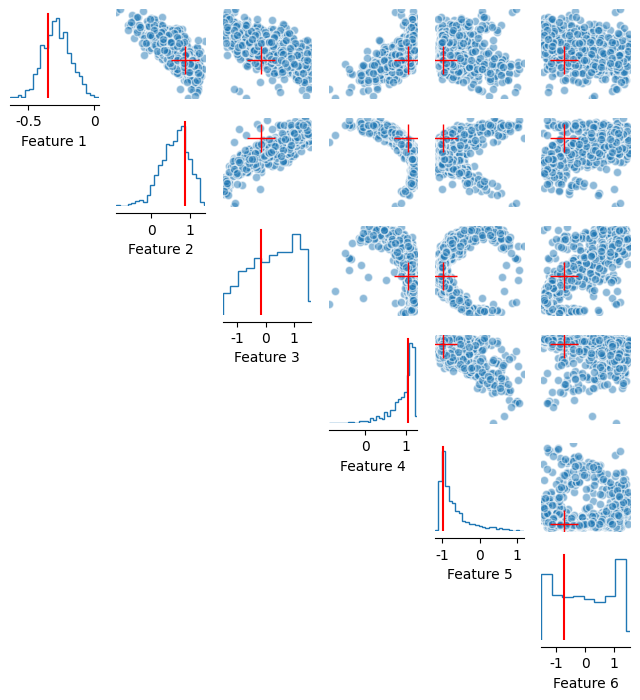

In [48]:
x_pp1 = simulator(samples1).squeeze()

_ = analysis.pairplot(
    samples=x_pp1,
    points=obs1,
    upper="scatter",
    figsize=(8, 8),
    upper_kwargs=dict(marker=".", s=5),
    fig_kwargs=dict(
        points_offdiag=dict(marker="+", markersize=20),
        points_colors="red",
    ),
    labels=[rf"Feature {d+1}" for d in range(N)],
)

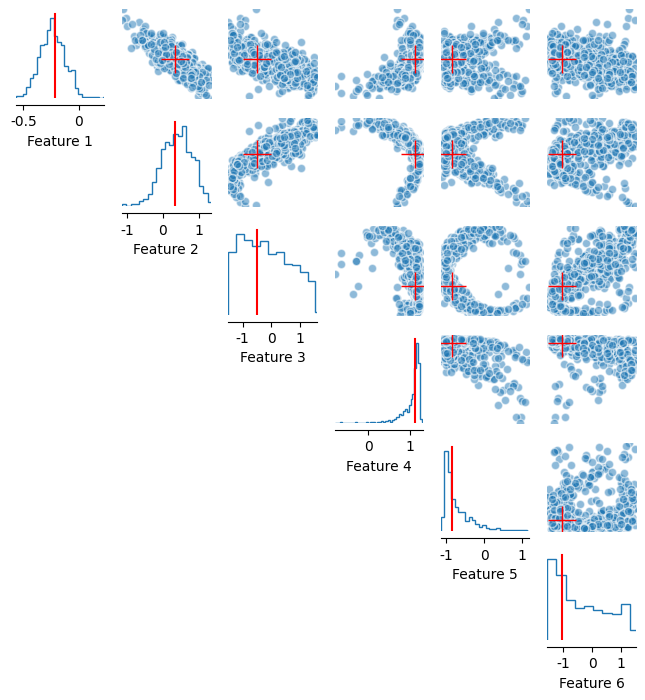

In [49]:
x_pp2 = simulator(samples2).squeeze()

_ = analysis.pairplot(
    samples=x_pp2,
    points=obs2,
    upper="scatter",
    figsize=(8, 8),
    upper_kwargs=dict(marker=".", s=5),
    fig_kwargs=dict(
        points_offdiag=dict(marker="+", markersize=20),
        points_colors="red",
    ),
    labels=[rf"Feature {d+1}" for d in range(N)],
)

**Simulation-Based Calibration**

Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

Calculating ranks for 200 sbc samples.:   0%|          | 0/200 [00:00<?, ?it/s]

kolmogorov-smirnov p-values 
 check_stats['ks_pvals'] = [0.35156193 0.3515618 ]
c2st accuracies 
check_stats['c2st_ranks'] = [0.535  0.4625]
- c2st accuracies check_stats['c2st_dap'] = [0.445  0.4925]


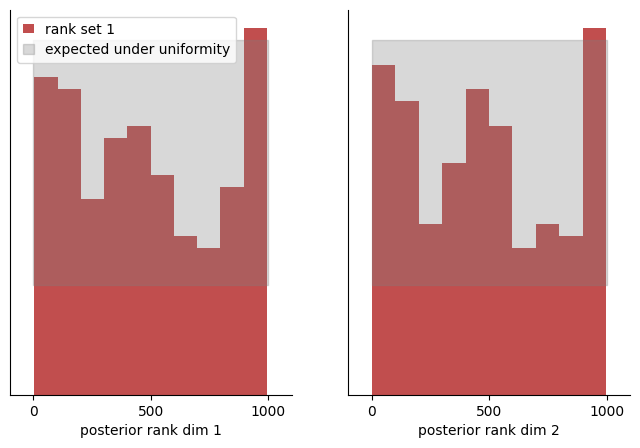

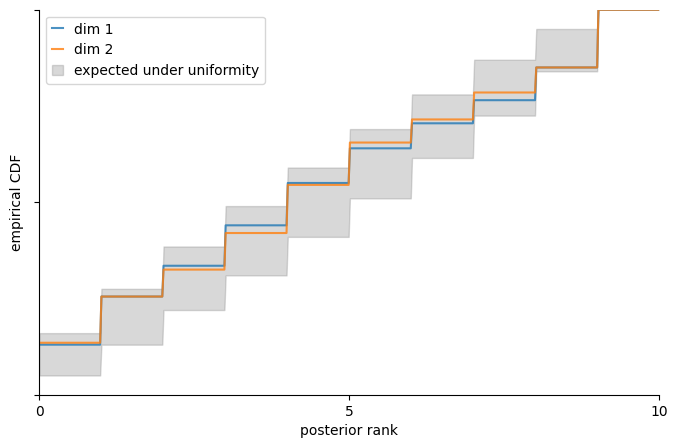

In [50]:
th_sbc = prior.sample((200, ))
x_sbc = simulator(th_sbc)

ranks, dap_samples = run_sbc(th_sbc, x_sbc, posterior, num_posterior_samples=1000, num_workers=4)

check_stats = check_sbc(ranks, th_sbc, dap_samples, num_posterior_samples=1000)
print(f"""kolmogorov-smirnov p-values \n check_stats['ks_pvals'] = {check_stats['ks_pvals'].numpy()}""")
print(f"c2st accuracies \ncheck_stats['c2st_ranks'] = {check_stats['c2st_ranks'].numpy()}")
print(f"- c2st accuracies check_stats['c2st_dap'] = {check_stats['c2st_dap'].numpy()}")

f, ax = sbc_rank_plot(ranks=ranks, num_posterior_samples=1000, plot_type="hist", num_bins=None)
f, ax = sbc_rank_plot(ranks, 1000, plot_type="cdf")

In [51]:
# use reduce_fns in order to map the test statistic to only one dimension
ranks, dap_samples = run_sbc(th_sbc, x_sbc, posterior, num_posterior_samples=1000, reduce_fns=posterior.log_prob)
check_stats = check_sbc(ranks, th_sbc, dap_samples, 1000)
print(check_stats)

Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

Calculating ranks for 200 sbc samples.:   0%|          | 0/200 [00:00<?, ?it/s]

{'ks_pvals': tensor([0.0684]), 'c2st_ranks': tensor([0.4850], dtype=torch.float64), 'c2st_dap': tensor([0.4950, 0.5025], dtype=torch.float64)}
